In [1]:
from llms.llm_ochestrator import LLMOchestrator
config_name = "gpt2-small-1024"
model_type = "classification"
ochestrator = LLMOchestrator(config_name, model_type)

ochestrator.model_config

{'vocab_size': 50257,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'model_name': 'gpt2-small-1024',
 'model_size': '124M',
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12,
 'context_length': 1024}

In [ ]:
#ochestrator.load_weight()

In [ ]:
# import torch

# torch.manual_seed(123)

# ochestrator.model.out_head = torch.nn.Linear(in_features=768, out_features=2)

# model = ochestrator.model

# for param in model.parameters():
#     param.requires_grad = False

# for param in model.trf_blocks[-1].parameters():
#     param.requires_grad = True

# for param in model.final_norm.parameters():
#     param.requires_grad = True

In [ ]:
#ochestrator.save_model("./trained_models/gpt2-small-1024-(124M)-classification.pth")

In [2]:
ochestrator.load_model("./trained_models/gpt2-small-1024-(124M)-classification.pth")

In [3]:
import torch
torch.manual_seed(123)
base_path = "./training_data/sms_spam_collection/"
train_loader, val_loader, test_loader = ochestrator.create_spamdata_dataloader(train_file_path=base_path+"train.csv",
                                       val_file_path=base_path+"validation.csv",
                                       test_file_path=base_path+"test.csv",
                                       batch_size=8                                       
                                       )

In [ ]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

In [ ]:
import torch
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = ochestrator.calc_loss_loader(train_loader, num_batches=5)
    val_loss = ochestrator.calc_loss_loader(val_loader, num_batches=5)
    test_loss = ochestrator.calc_loss_loader(test_loader, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

In [ ]:
import torch
torch.manual_seed(123)
train_accuracy = ochestrator.calc_accuracy_loader(train_loader)
val_accuracy = ochestrator.calc_accuracy_loader(val_loader)
test_accuracy = ochestrator.calc_accuracy_loader(test_loader)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

In [ ]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

ochestrator.generate_text(start_context=text_2, max_new_tokens=23)

In [ ]:
print(ochestrator.model)

In [ ]:
# Based on this causal attention mechanism, the last token contains the most information among all tokens
# because it's the only token that includes information about all other tokens
# Hence we are particulary interested in this last token, which we will finetune for the spam classification task


In [ ]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(ochestrator.classify_review(text_1, 500))

In [4]:
import torch
torch.manual_seed(123)
num_epochs = 5
train_losses, val_losses, train_acc, val_acc, examples_seen, track_lrs = ochestrator.train_classifier(
    train_loader=train_loader, 
    validation_loader=val_loader,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5, batch_size=8)



Ep 1 (Step 000000): Train loss 2.238, Val loss 2.913
Ep 1 (Step 000050): Train loss 0.694, Val loss 0.636
Ep 1 (Step 000100): Train loss 0.279, Val loss 0.571
Training accuracy: 82.50% | Validation accuracy: 82.50%
Ep 2 (Step 000150): Train loss 0.381, Val loss 0.469
Ep 2 (Step 000200): Train loss 0.182, Val loss 0.467
Ep 2 (Step 000250): Train loss 0.126, Val loss 0.127
Training accuracy: 95.00% | Validation accuracy: 100.00%
Ep 3 (Step 000300): Train loss 0.023, Val loss 0.036
Ep 3 (Step 000350): Train loss 0.119, Val loss 0.041
Training accuracy: 97.50% | Validation accuracy: 100.00%
Ep 4 (Step 000400): Train loss 0.270, Val loss 0.003
Ep 4 (Step 000450): Train loss 0.002, Val loss 0.252
Ep 4 (Step 000500): Train loss 0.002, Val loss 0.100
Training accuracy: 97.50% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.198, Val loss 0.024
Ep 5 (Step 000600): Train loss 0.001, Val loss 0.167
Training accuracy: 100.00% | Validation accuracy: 95.00%


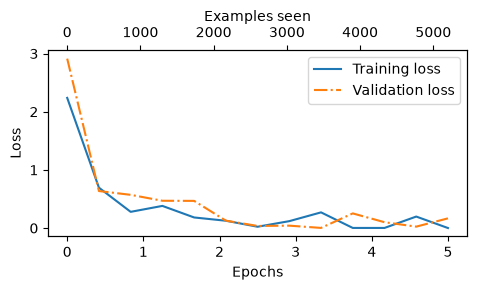

In [5]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

ochestrator.plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

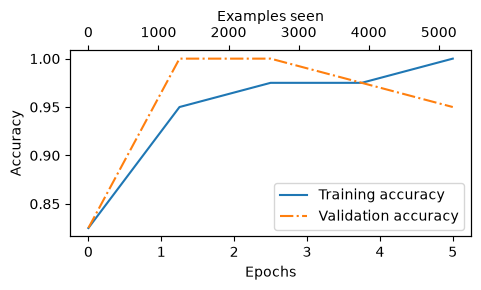

In [6]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_acc))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_acc))

ochestrator.plot_values(epochs_tensor, examples_seen_tensor, train_acc, val_acc, label="accuracy")

In [7]:

print(train_loader.dataset.max_length)
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(ochestrator.classify_review(text=text_1, max_length=train_loader.dataset.max_length))

120
spam


In [8]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(ochestrator.classify_review(text=text_2, max_length=train_loader.dataset.max_length))

not spam


In [9]:
train_accuracy = ochestrator.calc_accuracy_loader(train_loader)
val_accuracy = ochestrator.calc_accuracy_loader(val_loader)
test_accuracy = ochestrator.calc_accuracy_loader(test_loader)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 99.04%
Validation accuracy: 97.32%
Test accuracy: 96.00%


In [10]:
ochestrator.save_model("./trained_models/gpt2-small-1024-(124M)-classification-trained.pth")